In [2]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import scipy.ndimage as ndimage

## Effect 1: Blue print

In [3]:
def mag_sobel(img: np.ndarray) -> np.ndarray:
    Sh = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    Sv = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    img = img.astype(np.float32)
    img_h = ndimage.convolve(img, Sh)
    img_v = ndimage.convolve(img, Sv)
    return np.sqrt(np.power(img_h, 2) + np.power(img_v, 2))

In [4]:

def halftoning_effect(img: np.ndarray, block_size: int = 3) -> np.ndarray:
    """Aplica um efeito suave de halftoning criando uma malha de pontos.
    
    Args:
        img (np.ndarray): Imagem de entrada. Precisa estar no intervalo [0, 1] para os cálculos!
        block_size (int): Tamanho do bloco para a malha de halftoning.

    Returns:
        np.ndarray: Imagem com o efeito de halftoning aplicado. Imagem resultante estará no intervalo [0, 1].
    """
    h, w = img.shape[:2]
    y, x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    pattern = (np.sin(x * np.pi / block_size) * np.sin(y * np.pi / block_size) + 1.0) / 2.0
    
    # Expandir para ter canais como a imagem
    if img.ndim == 3:
        pattern = pattern[..., np.newaxis]
        
    # Combina a intensidade original com o padrão para texturizar
    return np.clip(img * (0.5 + 0.5 * pattern), 0, 1)

def rgb_to_grayscale(rgb: np.ndarray) -> np.ndarray:
    """Converte uma imagem RGB para escala de cinza usando a fórmula de luminosidade.
    
    Args:
        rgb (np.ndarray): Imagem RGB de entrada. Deve ter forma (H, W, 3) e valores no intervalo [0, 1].
    
    Returns:
        np.ndarray: Imagem em escala de cinza resultante, com forma (H, W) e valores no intervalo [0, 1].
    """
    return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])

def blueprint_effect(image: np.ndarray) -> np.ndarray:
    img_float = image.astype(np.float64) / 255.0
    gray = rgb_to_grayscale(img_float)

    # Detecção de borda
    edges = mag_sobel(gray)
    edges = edges / np.max(edges)
    
    # Thresholding e Dilatação para clarear e tornar as linhas mais espessas/visíveis
    edges = np.where(edges > 0.1, edges, 0.0)
    edges = ndimage.maximum_filter(edges, size=5)
    
    # Mapeamento de cores (um tom de azul e um de branco)
    blue_bg = np.array([25, 84, 166]) / 255.0   # Fundo azul
    white_lines = np.array([255, 255, 255]) / 255.0 # Linhas brancas
    
    edges_expanded = edges[..., np.newaxis]
    blueprint = (edges_expanded * white_lines) + ((1.0 - edges_expanded) * blue_bg)
    
    # Aplica textura/halftoning simulando papel impresso
    blueprint_textured = halftoning_effect(blueprint, block_size=15)
    
    out_img = np.clip(blueprint_textured * 255.0, 0, 255).astype(np.uint8)
    
    return out_img

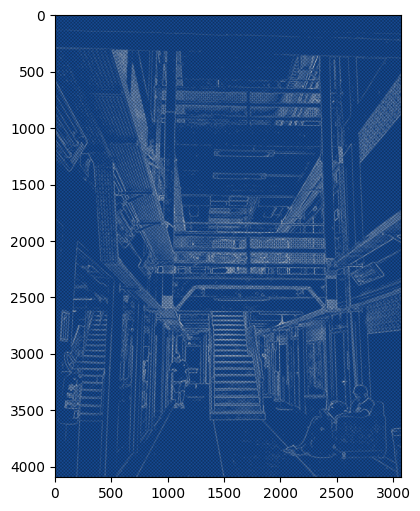

In [5]:
staircase_img = mpimg.imread('../../photo/257234_escadas.jpg')
staircase_img_bp = blueprint_effect(staircase_img)
plt.figure(figsize=(12, 6))
plt.imshow(staircase_img_bp)

## Efect 2: Industrial

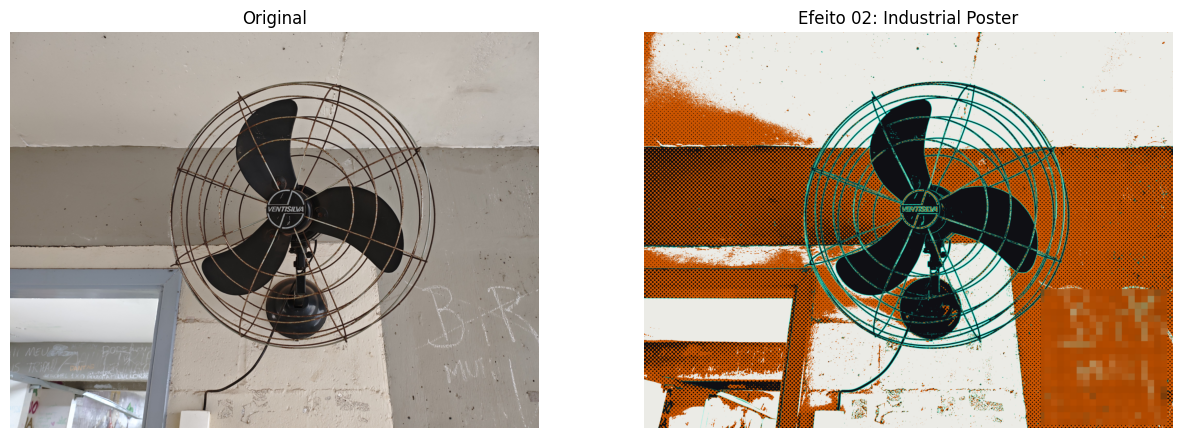

In [6]:
def pixelate_effect(img: np.ndarray, block_size: int = 50) -> np.ndarray:
    out = np.copy(img)
    h, w = img.shape[:2]
    
    h_adj = (h // block_size) * block_size
    w_adj = (w // block_size) * block_size
    
    if h_adj > 0 and w_adj > 0:
        if img.ndim == 3:
            blocks = img[:h_adj, :w_adj].reshape(h_adj // block_size, block_size, w_adj // block_size, block_size, img.shape[2])
        else:
            blocks = img[:h_adj, :w_adj].reshape(h_adj // block_size, block_size, w_adj // block_size, block_size)
        
        out[:h_adj, :w_adj] = np.repeat(np.repeat(blocks.mean(axis=(1, 3)), block_size, axis=0), block_size, axis=1)
            
    return out


def industrial_effect(image: np.ndarray) -> np.ndarray:
    img_float = image.astype(np.float64) / 255.0
        
    gray = rgb_to_grayscale(img_float) if img_float.ndim == 3 else img_float.copy()
    h, w = gray.shape
    
    # Mapeamento de Cores (paleta industrial)
    black = np.array([15, 15, 20]) / 255.0
    rust = np.array([204, 85, 0]) / 255.0
    cream = np.array([235, 235, 230]) / 255.0
    
    textured_dark = halftoning_effect(gray, block_size=9)
    textured_mid = halftoning_effect(gray, block_size=15)

    tritone = np.zeros((*gray.shape, 3))
    
    # Aplicar as cores com base no limiar das suas respectivas texturas geradas
    mask_dark = textured_dark < 0.35
    mask_mid = (textured_mid >= 0.35) & (textured_mid < 0.65)
    mask_light = gray >= 0.65 # Áreas claras sem halftoning
    
    tritone[mask_dark] = black
    tritone[mask_mid] = rust
    tritone[mask_light] = cream
            
    # Detecção de Borda (Neon Lines)
    edges = mag_sobel(gray)
    edges = edges /  np.max(edges)
        
    edges = np.where(edges > 0.2, edges, 0.0)
    edges = ndimage.maximum_filter(edges, size=3) # Dilatação para estilo neon

    cyan_neon = np.array([0, 255, 230]) / 255.0
    edges_expanded = edges[..., np.newaxis]
    
    # Mesclar a camada base tritone com as linhas neon por cima
    out_img = tritone * (1.0 - edges_expanded) + cyan_neon * edges_expanded
    
    # Pixelização Seletiva no quadrante inferior direito
    pixelated_img = pixelate_effect(out_img, block_size=50)
    
    # Aplicar apenas no quadrante inferior direito
    split_x = int(w * 0.75) 
    split_y = int(h * 0.65) 
    out_img[split_y:, split_x:] = pixelated_img[split_y:, split_x:]

    return np.clip(out_img * 255.0, 0, 255).astype(np.uint8)


fan_img = mpimg.imread('../../photo/257234_ventilador.jpg')
fan_img_effect = industrial_effect(fan_img)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(fan_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Efeito 02: Industrial Poster")
plt.imshow(fan_img_effect)
plt.axis('off')
plt.show()

## Efeito 3: gloomy

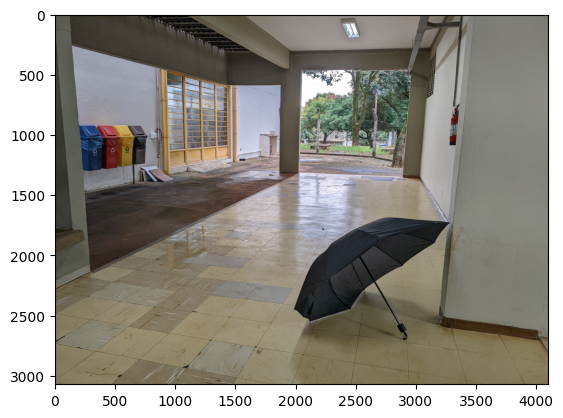

In [8]:
umbrella_img = mpimg.imread('../../photo/257234_guarda-chuva.jpg')
plt.figure()
plt.imshow(umbrella_img)

In [ ]:
def vignette_effect(image: np.ndarray, strength: float = 0.5) -> np.ndarray:
    h, w, _ = image.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    center_y, center_x = h / 2, w / 2
    distance_from_center = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    max_distance = np.sqrt(center_x ** 2 + center_y ** 2)
    
    vignette_mask = 1 - (distance_from_center / max_distance) * strength
    vignette_mask = np.clip(vignette_mask, 0, 1)
    
    vignette_mask = vignette_mask.reshape(h, w, 1) 
    
    return np.clip(image * vignette_mask, 0, 255).astype(np.uint8)


(np.float64(-0.5), np.float64(4095.5), np.float64(3071.5), np.float64(-0.5))

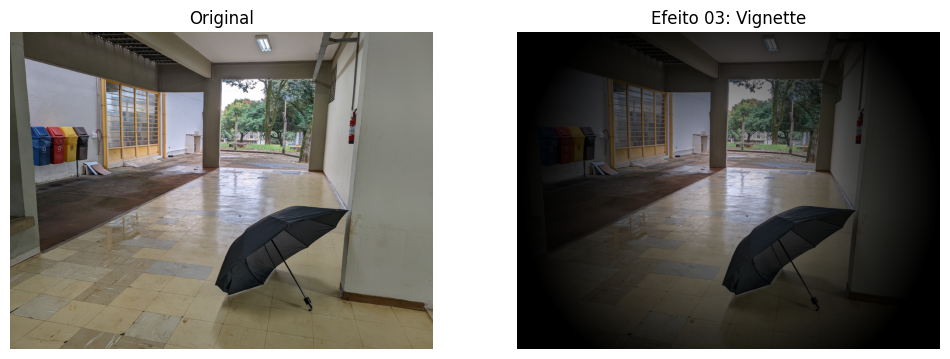

In [16]:
vignette_img = vignette_effect(umbrella_img, strength=1.25)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(umbrella_img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Efeito 03: Vignette")
plt.imshow(vignette_img)
plt.axis('off')

In [24]:
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb

def alter_saturation(image: np.ndarray, saturation_factor: float) -> np.ndarray:
    hsv = rgb_to_hsv(image / 255.0)
    hsv[..., 1] *= saturation_factor
    hsv[..., 1] = np.clip(hsv[..., 1], 0, 1)
    
    return (hsv_to_rgb(hsv) * 255).astype(np.uint8)

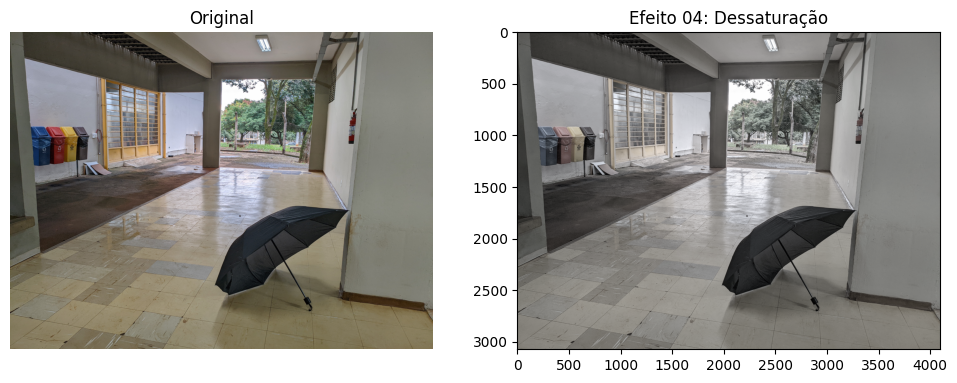

In [25]:
unsaturated_img = alter_saturation(umbrella_img, saturation_factor=0.25)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(umbrella_img)        
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Efeito 04: Dessaturação")
plt.imshow(unsaturated_img)

In [26]:
unsaturated_img

array([[[ 89,  92,  86],
        [ 91,  94,  88],
        [ 93,  95,  89],
        ...,
        [128, 129, 125],
        [126, 127, 123],
        [125, 126, 122]],

       [[ 83,  86,  80],
        [ 89,  92,  86],
        [ 93,  95,  89],
        ...,
        [126, 127, 123],
        [127, 128, 124],
        [128, 129, 125]],

       [[ 80,  83,  77],
        [ 84,  87,  81],
        [ 93,  95,  89],
        ...,
        [129, 130, 126],
        [130, 131, 127],
        [132, 133, 128]],

       ...,

       [[128, 125, 117],
        [118, 115, 107],
        [132, 129, 121],
        ...,
        [127, 123, 116],
        [129, 125, 118],
        [133, 129, 122]],

       [[131, 128, 119],
        [122, 119, 110],
        [134, 131, 122],
        ...,
        [135, 131, 124],
        [136, 132, 125],
        [139, 135, 128]],

       [[137, 134, 125],
        [131, 128, 119],
        [135, 132, 123],
        ...,
        [133, 129, 122],
        [134, 130, 123],
        [135, 131, 124]]

In [29]:
def color_quantization_effect(image: np.ndarray, num_colors: int = 8) -> np.ndarray:
    img = Image.fromarray(image)
    quantized_img = img.quantize(colors=num_colors, method=Image.ADAPTIVE)
    quantized_array = np.array(quantized_img.convert('RGB'))

    return np.clip(quantized_array, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(4095.5), np.float64(3071.5), np.float64(-0.5))

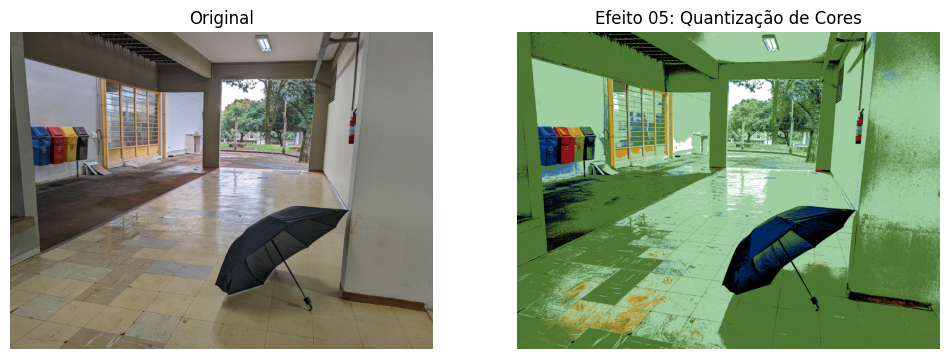

In [30]:
quantized_img = color_quantization_effect(umbrella_img, num_colors=8)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(umbrella_img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Efeito 05: Quantização de Cores")
plt.imshow(quantized_img)
plt.axis('off')

In [34]:
def noise_effect(image: np.ndarray, noise_level: float = 0.05) -> np.ndarray:
    noise = np.random.normal(0, noise_level * 255, image.shape).astype(np.float32)
    noisy_image = image.astype(np.float32) + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

In [47]:
def gloomy_effect(image: np.ndarray) -> np.ndarray:
    img = color_quantization_effect(image, num_colors=4)
    img = noise_effect(img, noise_level=0.25)
    img = alter_saturation(img, saturation_factor=0.5)
    img = vignette_effect(img, strength=1.15)
    
    return img

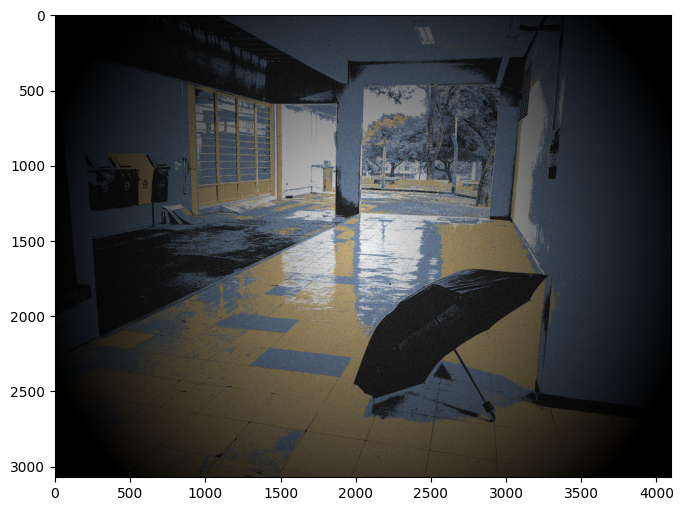

In [48]:
gloomy_img = gloomy_effect(umbrella_img)

plt.figure(figsize=(12, 6))
plt.imshow(gloomy_img)

In [53]:
gloomy_img[2000, 2000]

array([155, 180,  90], dtype=uint8)